In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
 
 
def load_loss_histories(root_dir: str) -> list[list[float]]:
    """
    Iterates over subfolders in root_dir, reads one file per subfolder,
    and returns a list of loss histories (each history is a list of floats).
    """
    histories = []
 
    for subfolder in sorted(os.listdir(root_dir)):
        subfolder_path = os.path.join(root_dir, subfolder)
        if not os.path.isdir(subfolder_path):
            continue
 
        for filename in os.listdir(subfolder_path):
            filepath = os.path.join(subfolder_path, filename)
            if not os.path.isfile(filepath):
                continue
 
            with open(filepath) as f:
                losses = [float(line.strip()) for line in f if line.strip()]
            histories.append(losses)
            # break  # one file per subfolder
 
    return histories
 

In [3]:
total_grad = load_loss_histories("results/train_grad")
total_loss = load_loss_histories("results/train_loss")
val_acc = load_loss_histories("results/val_acc")
val_loss = load_loss_histories("results/val_loss")

In [4]:
import matplotlib.pyplot as plt


def plot_loss_histories(histories: list[list[float]]) -> None:
    for i, run in enumerate(histories):
        # plt.plot(losses, label=f"Run {i + 1}")
        plt.plot([x for x in range(len(run))], run)
        

    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
def growing_mean(hist):
    means = []
    total = 0.0
    for i, value in enumerate(hist):
        total += value
        means.append(total / (i + 1))
    return means

In [6]:
grad_means = [growing_mean(run) for run in total_grad]

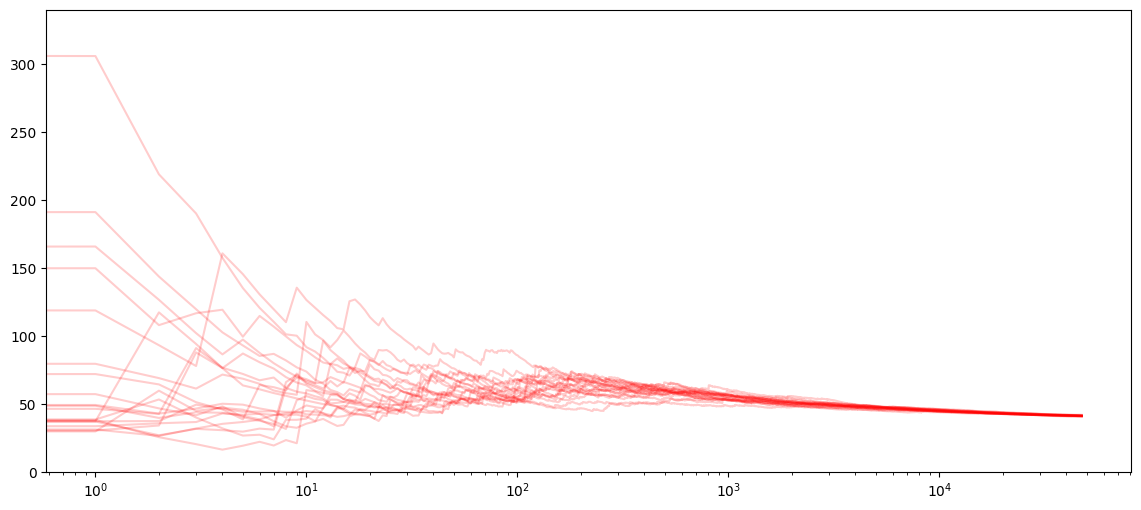

In [7]:
plt.figure(figsize=(14, 6))

for gradmean in grad_means:
    plt.plot(gradmean, alpha=0.2, c="red")

plt.xscale("log")
plt.ylim(0,340)
plt.show()

In [8]:
def upper_bound(T, delta):
    res = []
    for i in range(T):
        if i == 0:
            res.append(0)
        else:
            res.append(np.log(i / delta) / np.pow(i, -(1/5)))
    return res

In [9]:
halfway = upper_bound(len(grad_means[0]), 0.2)

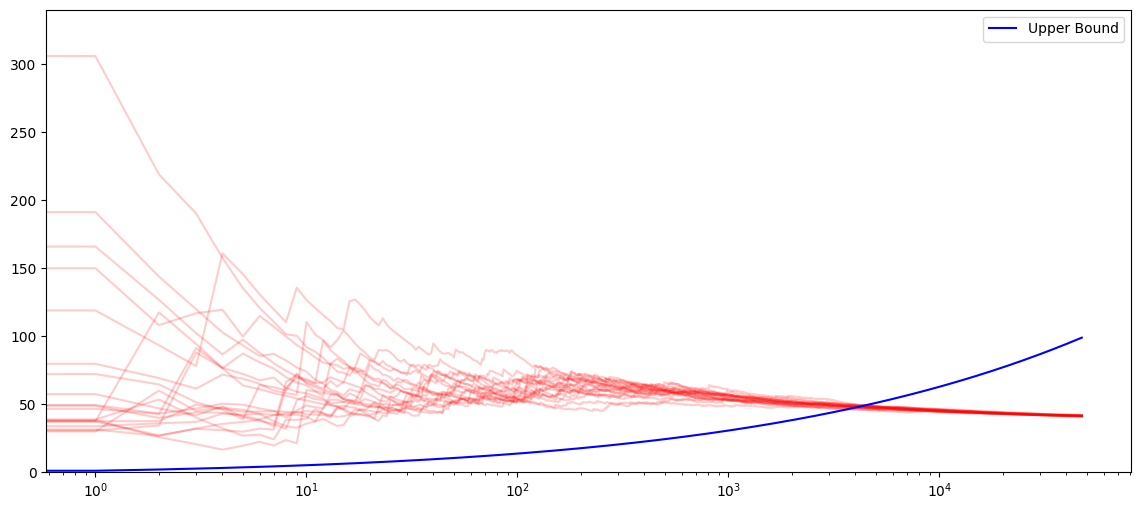

In [10]:
halfway = upper_bound(len(grad_means[0]), 0.5)

plt.figure(figsize=(14, 6))

for gradmean in grad_means:
    plt.plot(gradmean, alpha=0.2, c="red")


plt.plot(halfway, c="blue", label="Upper Bound")
plt.legend()
plt.xscale("log")
plt.ylim(0,340)
plt.show()

In [11]:
def moving_avg(hist, window_size=10):
    if len(hist) < window_size:
        return hist
    return np.convolve(hist, np.ones(window_size)/window_size, mode='valid')

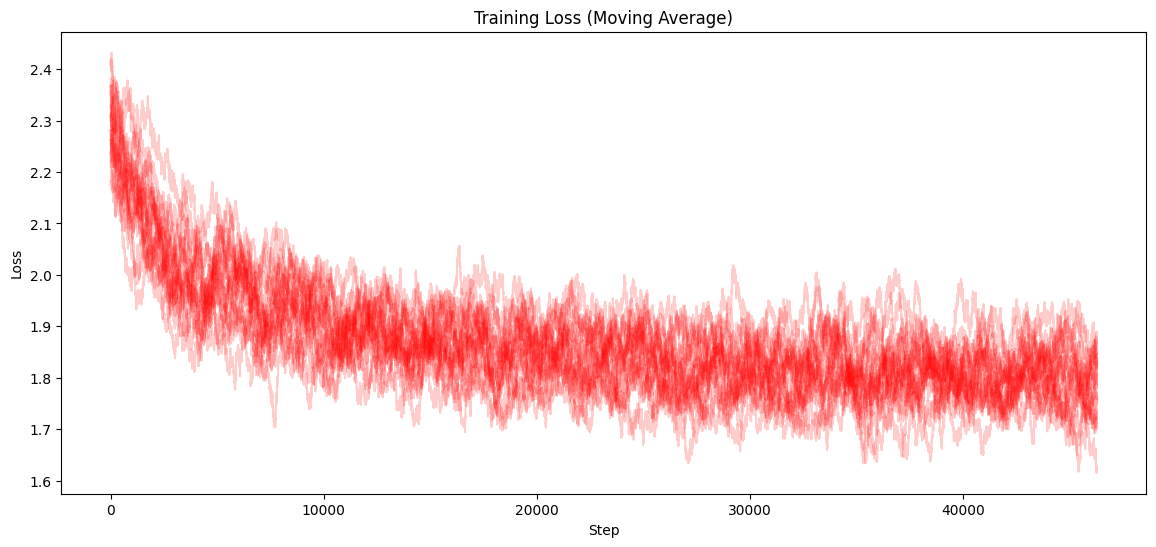

In [28]:
tot_loss_avg = [moving_avg(run, 1000) for run in total_loss]

plt.figure(figsize=(14, 6))
for run in tot_loss_avg:
    plt.plot(run, alpha=0.2, c="red")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss (Moving Average)")
plt.show()

In [19]:
berta_loss = load_loss_histories("bertaburns/train_loss")
berta_acc = load_loss_histories("bertaburns/val_acc")

In [20]:
berta_acc

[[0.5886731490353557, 0.5854483140478867],
 [0.5858924638893196, 0.5825495807615202],
 [0.5890022106756286, 0.5902570732746217],
 [0.5809648233015137, 0.6002470582893156]]

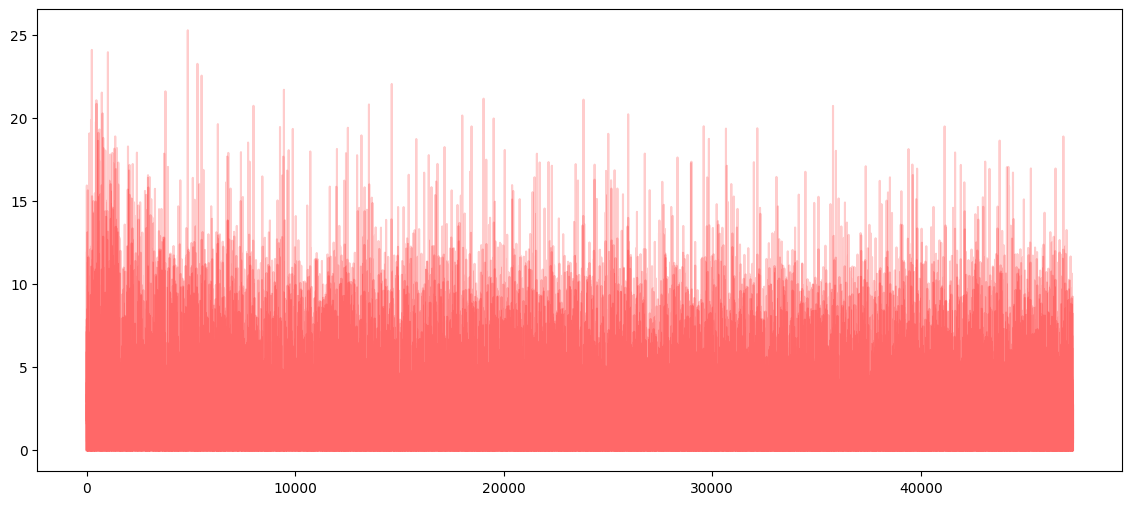

In [21]:
plt.figure(figsize=(14, 6))

for i, loss in enumerate(berta_loss):
    plt.plot(loss, alpha=0.2, c="red", label="Berta Loss: Run {i + 1}")

# plt.xscale("log")
# plt.ylim(0,340)
plt.show()

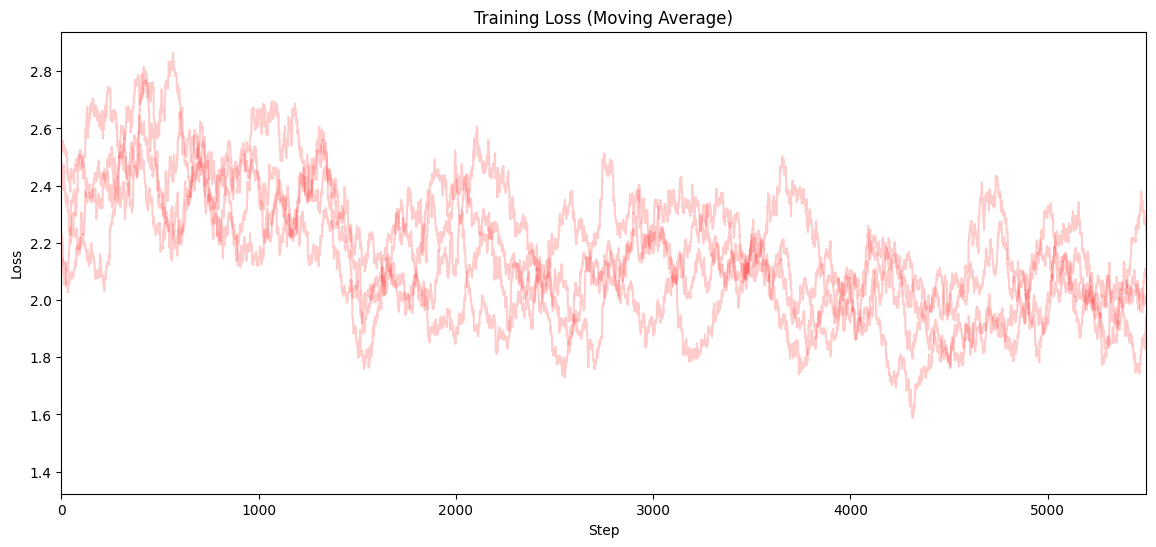

In [27]:
bert_loss_avg = [moving_avg(run, 200) for run in berta_loss]

plt.figure(figsize=(14, 6))
for run in bert_loss_avg:
    plt.plot(run, alpha=0.2, c="red")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.xlim(0, 5500)
plt.title("Training Loss (Moving Average)")
plt.show()